<a href="https://colab.research.google.com/github/MateenahJAHAN/adease-wikipedia-timeseries-forecasting/blob/main/AdEase_Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PROBLEM STATEMENT:**
AdEase is a digital advertising company that places ads on Wikipedia pages. To optimize ad placement, AdEase needs to predict daily page views for Wikipedia articles across different languages. In this case study, I am working with 550 days of historical view data for 145,000 Wikipedia pages, along with a campaign indicator variable for English pages. My goal is to perform exploratory data analysis, check stationarity, and build time series forecasting models (ARIMA, SARIMAX, Prophet) to predict future page views by language.

**GOAL:**
To build time series forecasting models (ARIMA, SARIMAX, and Facebook Prophet) that can accurately predict daily Wikipedia page views across multiple languages. The aim is to achieve a MAPE in the range of 4-8%, enabling AdEase to optimize ad placement strategy for clients across different regions.



In [ ]:
#import libraries
# Basic data handling
import pandas as pd# table
import numpy as np# calculation

# Visualization
import matplotlib.pyplot as plt#graphs
import seaborn as sns# graphs

# Time series — stationarity tests
from statsmodels.tsa.stattools import adfuller

# Time series — decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# ACF and PACF plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ARIMA and SARIMAX models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Evaluation metric
from sklearn.metrics import mean_absolute_percentage_error

# Utilities
import warnings
warnings.filterwarnings('ignore')

# For grid search later
import itertools

# Display settings — taaki pandas saare columns dikhae
pd.set_option('display.max_columns', None)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
!pip install prophet -q

In [ ]:
from prophet import Prophet

In [ ]:
import pandas as pd

exog_df = pd.read_csv('/content/Exog_Campaign_eng')
train_df = pd.read_csv('/content/train_1 (1).csv')



In [ ]:
print(exog_df.shape)
print(train_df.shape)

(550, 1)
(33434, 551)


**STEP 1B: Basic Exploration (Structure & Characteristics)**

In [ ]:
train_df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,2015-07-11,2015-07-12,2015-07-13,2015-07-14,2015-07-15,2015-07-16,2015-07-17,2015-07-18,2015-07-19,2015-07-20,2015-07-21,2015-07-22,2015-07-23,2015-07-24,2015-07-25,2015-07-26,2015-07-27,2015-07-28,2015-07-29,2015-07-30,2015-07-31,2015-08-01,2015-08-02,2015-08-03,2015-08-04,2015-08-05,2015-08-06,2015-08-07,2015-08-08,2015-08-09,2015-08-10,2015-08-11,2015-08-12,2015-08-13,2015-08-14,2015-08-15,2015-08-16,2015-08-17,2015-08-18,2015-08-19,2015-08-20,2015-08-21,2015-08-22,2015-08-23,2015-08-24,2015-08-25,2015-08-26,2015-08-27,2015-08-28,2015-08-29,2015-08-30,2015-08-31,2015-09-01,2015-09-02,2015-09-03,2015-09-04,2015-09-05,2015-09-06,2015-09-07,2015-09-08,2015-09-09,2015-09-10,2015-09-11,2015-09-12,2015-09-13,2015-09-14,2015-09-15,2015-09-16,2015-09-17,2015-09-18,2015-09-19,2015-09-20,2015-09-21,2015-09-22,2015-09-23,2015-09-24,2015-09-25,2015-09-26,2015-09-27,2015-09-28,2015-09-29,2015-09-30,2015-10-01,2015-10-02,2015-10-03,2015-10-04,2015-10-05,2015-10-06,2015-10-07,2015-10-08,2015-10-09,2015-10-10,2015-10-11,2015-10-12,2015-10-13,2015-10-14,2015-10-15,2015-10-16,2015-10-17,2015-10-18,2015-10-19,2015-10-20,2015-10-21,2015-10-22,2015-10-23,2015-10-24,2015-10-25,2015-10-26,2015-10-27,2015-10-28,2015-10-29,2015-10-30,2015-10-31,2015-11-01,2015-11-02,2015-11-03,2015-11-04,2015-11-05,2015-11-06,2015-11-07,2015-11-08,2015-11-09,2015-11-10,2015-11-11,2015-11-12,2015-11-13,2015-11-14,2015-11-15,2015-11-16,2015-11-17,2015-11-18,2015-11-19,2015-11-20,2015-11-21,2015-11-22,2015-11-23,2015-11-24,2015-11-25,2015-11-26,2015-11-27,2015-11-28,2015-11-29,2015-11-30,2015-12-01,2015-12-02,2015-12-03,2015-12-04,2015-12-05,2015-12-06,2015-12-07,2015-12-08,2015-12-09,2015-12-10,2015-12-11,2015-12-12,2015-12-13,2015-12-14,2015-12-15,2015-12-16,2015-12-17,2015-12-18,2015-12-19,2015-12-20,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-26,2015-12-27,2015-12-28,2015-12-29,2015-12-30,2015-12-31,2016-01-01,2016-01-02,2016-01-03,2016-01-04,2016-01-05,2016-01-06,2016-01-07,2016-01-08,2016-01-09,2016-01-10,2016-01-11,2016-01-12,2016-01-13,2016-01-14,2016-01-15,2016-01-16,2016-01-17,2016-01-18,2016-01-19,2016-01-20,2016-01-21,2016-01-22,2016-01-23,2016-01-24,2016-01-25,2016-01-26,2016-01-27,2016-01-28,2016-01-29,2016-01-30,2016-01-31,2016-02-01,2016-02-02,2016-02-03,2016-02-04,2016-02-05,2016-02-06,2016-02-07,2016-02-08,2016-02-09,2016-02-10,2016-02-11,2016-02-12,2016-02-13,2016-02-14,2016-02-15,2016-02-16,2016-02-17,2016-02-18,2016-02-19,2016-02-20,2016-02-21,2016-02-22,2016-02-23,2016-02-24,2016-02-25,2016-02-26,2016-02-27,2016-02-28,2016-02-29,2016-03-01,2016-03-02,2016-03-03,2016-03-04,2016-03-05,2016-03-06,2016-03-07,2016-03-08,2016-03-09,2016-03-10,2016-03-11,2016-03-12,2016-03-13,2016-03-14,2016-03-15,2016-03-16,2016-03-17,2016-03-18,2016-03-19,2016-03-20,2016-03-21,2016-03-22,2016-03-23,2016-03-24,2016-03-25,2016-03-26,2016-03-27,2016-03-28,2016-03-29,2016-03-30,2016-03-31,2016-04-01,2016-04-02,2016-04-03,2016-04-04,2016-04-05,2016-04-06,2016-04-07,2016-04-08,2016-04-09,2016-04-10,2016-04-11,2016-04-12,2016-04-13,2016-04-14,2016-04-15,2016-04-16,2016-04-17,2016-04-18,2016-04-19,2016-04-20,2016-04-21,2016-04-22,2016-04-23,2016-04-24,2016-04-25,2016-04-26,2016-04-27,2016-04-28,2016-04-29,2016-04-30,2016-05-01,2016-05-02,2016-05-03,2016-05-04,2016-05-05,2016-05-06,2016-05-07,2016-05-08,2016-05-09,2016-05-10,2016-05-11,2016-05-12,2016-05-13,2016-05-14,2016-05-15,2016-05-16,2016-05-17,2016-05-18,2016-05-19,2016-05-20,2016-05-21,2016-05-22,2016-05-23,2016-05-24,2016-05-25,2016-05-26,2016-05-27,2016-05-28,2016-05-29,2016-05-30,2016-05-31,2016-06-01,2016-06-02,2016-06-03,2016-06-04,2016-06-05,2016-06-06,2016-06-07,2016-06-08,2016-06-09,2016-06-10,2016-06-11,2016-06-12,2016-06-13,2016-06-14,2016-06-15,2016-06-16,2016-06-17,2016-06-18,2016-06-19,2016-06-20,2016-06-21,2016-06-22,2016-06-23,2016-06-24,2016-06-25,2016-06-26,2016-06-27,2

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33434 entries, 0 to 33433
Columns: 551 entries, Page to 2016-12-31
dtypes: float64(550), object(1)
memory usage: 140.5+ MB


In [ ]:
train_df.describe()

,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,2015-07-11,2015-07-12,2015-07-13,2015-07-14,2015-07-15,2015-07-16,2015-07-17,2015-07-18,2015-07-19,2015-07-20,2015-07-21,2015-07-22,2015-07-23,2015-07-24,2015-07-25,2015-07-26,2015-07-27,2015-07-28,2015-07-29,2015-07-30,2015-07-31,2015-08-01,2015-08-02,2015-08-03,2015-08-04,2015-08-05,2015-08-06,2015-08-07,2015-08-08,2015-08-09,2015-08-10,2015-08-11,2015-08-12,2015-08-13,2015-08-14,2015-08-15,2015-08-16,2015-08-17,2015-08-18,2015-08-19,2015-08-20,2015-08-21,2015-08-22,2015-08-23,2015-08-24,2015-08-25,2015-08-26,2015-08-27,2015-08-28,2015-08-29,2015-08-30,2015-08-31,2015-09-01,2015-09-02,2015-09-03,2015-09-04,2015-09-05,2015-09-06,2015-09-07,2015-09-08,2015-09-09,2015-09-10,2015-09-11,2015-09-12,2015-09-13,2015-09-14,2015-09-15,2015-09-16,2015-09-17,2015-09-18,2015-09-19,2015-09-20,2015-09-21,2015-09-22,2015-09-23,2015-09-24,2015-09-25,2015-09-26,2015-09-27,2015-09-28,2015-09-29,2015-09-30,2015-10-01,2015-10-02,2015-10-03,2015-10-04,2015-10-05,2015-10-06,2015-10-07,2015-10-08,2015-10-09,2015-10-10,2015-10-11,2015-10-12,2015-10-13,2015-10-14,2015-10-15,2015-10-16,2015-10-17,2015-10-18,2015-10-19,2015-10-20,2015-10-21,2015-10-22,2015-10-23,2015-10-24,2015-10-25,2015-10-26,2015-10-27,2015-10-28,2015-10-29,2015-10-30,2015-10-31,2015-11-01,2015-11-02,2015-11-03,2015-11-04,2015-11-05,2015-11-06,2015-11-07,2015-11-08,2015-11-09,2015-11-10,2015-11-11,2015-11-12,2015-11-13,2015-11-14,2015-11-15,2015-11-16,2015-11-17,2015-11-18,2015-11-19,2015-11-20,2015-11-21,2015-11-22,2015-11-23,2015-11-24,2015-11-25,2015-11-26,2015-11-27,2015-11-28,2015-11-29,2015-11-30,2015-12-01,2015-12-02,2015-12-03,2015-12-04,2015-12-05,2015-12-06,2015-12-07,2015-12-08,2015-12-09,2015-12-10,2015-12-11,2015-12-12,2015-12-13,2015-12-14,2015-12-15,2015-12-16,2015-12-17,2015-12-18,2015-12-19,2015-12-20,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-26,2015-12-27,2015-12-28,2015-12-29,2015-12-30,2015-12-31,2016-01-01,2016-01-02,2016-01-03,2016-01-04,2016-01-05,2016-01-06,2016-01-07,2016-01-08,2016-01-09,2016-01-10,2016-01-11,2016-01-12,2016-01-13,2016-01-14,2016-01-15,2016-01-16,2016-01-17,2016-01-18,2016-01-19,2016-01-20,2016-01-21,2016-01-22,2016-01-23,2016-01-24,2016-01-25,2016-01-26,2016-01-27,2016-01-28,2016-01-29,2016-01-30,2016-01-31,2016-02-01,2016-02-02,2016-02-03,2016-02-04,2016-02-05,2016-02-06,2016-02-07,2016-02-08,2016-02-09,2016-02-10,2016-02-11,2016-02-12,2016-02-13,2016-02-14,2016-02-15,2016-02-16,2016-02-17,2016-02-18,2016-02-19,2016-02-20,2016-02-21,2016-02-22,2016-02-23,2016-02-24,2016-02-25,2016-02-26,2016-02-27,2016-02-28,2016-02-29,2016-03-01,2016-03-02,2016-03-03,2016-03-04,2016-03-05,2016-03-06,2016-03-07,2016-03-08,2016-03-09,2016-03-10,2016-03-11,2016-03-12,2016-03-13,2016-03-14,2016-03-15,2016-03-16,2016-03-17,2016-03-18,2016-03-19,2016-03-20,2016-03-21,2016-03-22,2016-03-23,2016-03-24,2016-03-25,2016-03-26,2016-03-27,2016-03-28,2016-03-29,2016-03-30,2016-03-31,2016-04-01,2016-04-02,2016-04-03,2016-04-04,2016-04-05,2016-04-06,2016-04-07,2016-04-08,2016-04-09,2016-04-10,2016-04-11,2016-04-12,2016-04-13,2016-04-14,2016-04-15,2016-04-16,2016-04-17,2016-04-18,2016-04-19,2016-04-20,2016-04-21,2016-04-22,2016-04-23,2016-04-24,2016-04-25,2016-04-26,2016-04-27,2016-04-28,2016-04-29,2016-04-30,2016-05-01,2016-05-02,2016-05-03,2016-05-04,2016-05-05,2016-05-06,2016-05-07,2016-05-08,2016-05-09,2016-05-10,2016-05-11,2016-05-12,2016-05-13,2016-05-14,2016-05-15,2016-05-16,2016-05-17,2016-05-18,2016-05-19,2016-05-20,2016-05-21,2016-05-22,2016-05-23,2016-05-24,2016-05-25,2016-05-26,2016-05-27,2016-05-28,2016-05-29,2016-05-30,2016-05-31,2016-06-01,2016-06-02,2016-06-03,2016-06-04,2016-06-05,2016-06-06,2016-06-07,2016-06-08,2016-06-09,2016-06-10,2016-06-11,2016-06-12,2016-06-13,2016-06-14,2016-06-15,2016-06-16,2016-06-17,2016-06-18,2016-06-19,2016-06-20,2016-06-21,2016-06-22,2016-06-23,2016-06-24,2016-06-25,2016-06-26,2016-06-27,2016-0

In [ ]:
total_missing = train_df.isnull().sum().sum()
total_cells = train_df.shape[0] * train_df.shape[1]
missing_pct = (total_missing / total_cells) * 100

print(f"Total missing values: {total_missing:,}")
print(f"Total cells: {total_cells:,}")
print(f"Percentage missing: {missing_pct:.2f}%")

# How many pages have at least 1 missing value
pages_with_missing = (train_df.isnull().sum(axis=1) > 0).sum()
print(f"\nPages with at least 1 missing value: {pages_with_missing:,}")
print(f"Percentage of pages affected: {(pages_with_missing/train_df.shape[0])*100:.2f}%")

Total missing values: 1,689,350
Total cells: 18,422,134
Percentage missing: 9.17%

Pages with at least 1 missing value: 7,560
Percentage of pages affected: 22.61%


In [ ]:
print("Duplicate rows in train_df:", train_df.duplicated().sum())
print("Duplicate page names in train_df:", train_df['Page'].duplicated().sum())

Duplicate rows in train_df: 0
Duplicate page names in train_df: 0


**Exog file ke saath same exploration**

In [ ]:
print("===== EXOG HEAD =====")
print(exog_df.head())

print("\n===== EXOG INFO =====")
exog_df.info()

print("\n===== EXOG MISSING =====")
print(exog_df.isnull().sum())

print("\n===== EXOG STATS =====")
print(exog_df.describe())

# Special check — kitne din campaign tha
print("\n===== CAMPAIGN COUNT =====")
print(exog_df.iloc[:, -1].value_counts())  # last column = campaign 0/1

===== EXOG HEAD =====
   Exog
0     0
1     0
2     0
3     0
4     0

===== EXOG INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Exog    550 non-null    int64
dtypes: int64(1)
memory usage: 4.4 KB

===== EXOG MISSING =====
Exog    0
dtype: int64

===== EXOG STATS =====
             Exog
count  550.000000
mean     0.098182
std      0.297831
min      0.000000
25%      0.000000
50%      0.000000
75%      0.000000
max      1.000000

===== CAMPAIGN COUNT =====
Exog
0    496
1     54
Name: count, dtype: int64


**STEP 2: Exploratory Data Analysis**

define function

In [ ]:
def split_page_name(page):
    """
    Splits a Wikipedia page string into 4 parts:
    title, language, access type, access origin.

    Example input: '2NE1_zh.wikipedia.org_all-access_spider'
    Output: ('2NE1', 'zh', 'all-access', 'spider')
    """
    # Split from RIGHT, max 3 splits
    # (so title remains intact even if it contains underscores)
    parts = page.rsplit('_', 3)

    title = parts[0]
    language_domain = parts[1]   # e.g. 'zh.wikipedia.org'
    access = parts[2]            # e.g. 'all-access'
    origin = parts[3]            # e.g. 'spider'

    # Extract just the language code from 'xx.wikipedia.org'
    language = language_domain.split('.')[0]

    return title, language, access, origin

In [ ]:
# Quick test on one page name
test = split_page_name('2NE1_zh.wikipedia.org_all-access_spider')
print(test)

('2NE1', 'zh', 'all-access', 'spider')


In [ ]:
# Apply function to all rows and create 4 new columns
train_df[['title', 'language', 'access', 'origin']] = train_df['Page'].apply(
    lambda x: pd.Series(split_page_name(x))
)

# Verify — first 5 rows ke new columns dekho
train_df[['Page', 'title', 'language', 'access', 'origin']].head()

,Page,title,language,access,origin
0,2NE1_zh.wikipedia.org_all-access_spider,2NE1,zh,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,2PM,zh,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,3C,zh,all-access,spider
3,4minute_zh.wikipedia.org_all-access_spider,4minute,zh,all-access,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,52_Hz_I_Love_You,zh,all-access,spider


In [ ]:
# Quick test on one page name
test = split_page_name('2NE1_zh.wikipedia.org_all-access_spider')
print(test)

('2NE1', 'zh', 'all-access', 'spider')


In [ ]:
# Apply function to all rows and create 4 new columns
train_df[['title', 'language', 'access', 'origin']] = train_df['Page'].apply(
    lambda x: pd.Series(split_page_name(x))
)

# Verify — first 5 rows ke new columns dekho
train_df[['Page', 'title', 'language', 'access', 'origin']].head()

,Page,title,language,access,origin
0,2NE1_zh.wikipedia.org_all-access_spider,2NE1,zh,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,2PM,zh,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,3C,zh,all-access,spider
3,4minute_zh.wikipedia.org_all-access_spider,4minute,zh,all-access,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,52_Hz_I_Love_You,zh,all-access,spider


**Viz 1: Languages distribution**

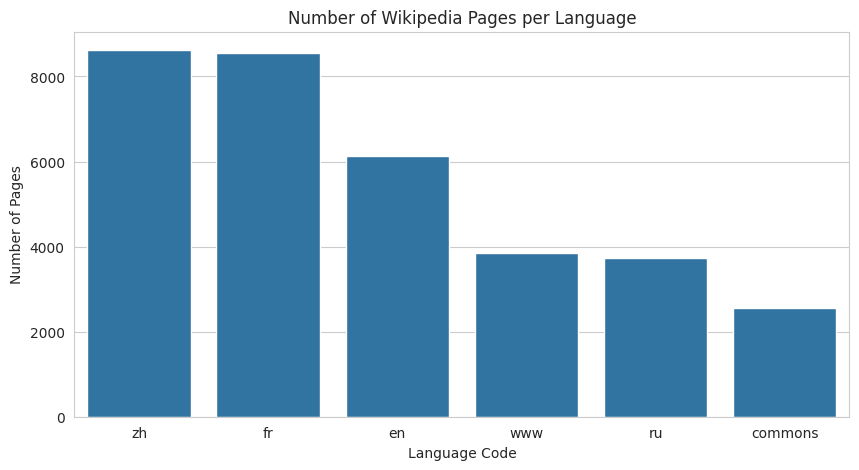


Language distribution:
language
zh         8620
fr         8546
en         6134
www        3855
ru         3729
commons    2550
Name: count, dtype: int64


In [ ]:
# Count of pages per language
plt.figure(figsize=(10, 5))
lang_counts = train_df['language'].value_counts()
sns.barplot(x=lang_counts.index, y=lang_counts.values)
plt.title('Number of Wikipedia Pages per Language')
plt.xlabel('Language Code')
plt.ylabel('Number of Pages')
plt.show()

print("\nLanguage distribution:")
print(lang_counts)

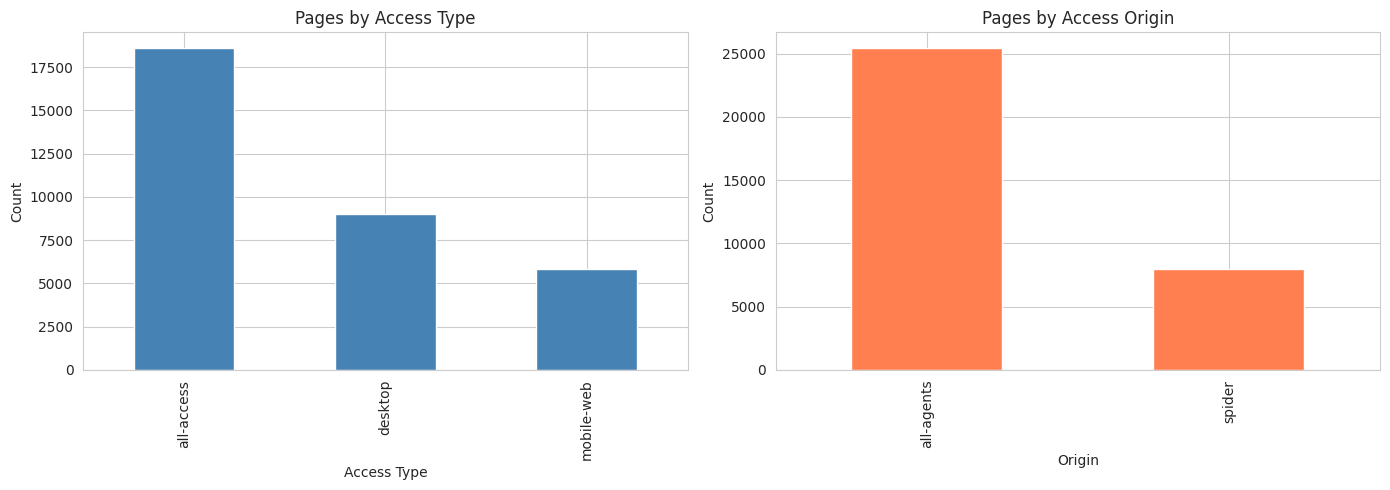

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Access types
train_df['access'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Pages by Access Type')
axes[0].set_xlabel('Access Type')
axes[0].set_ylabel('Count')

# Origins
train_df['origin'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Pages by Access Origin')
axes[1].set_xlabel('Origin')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

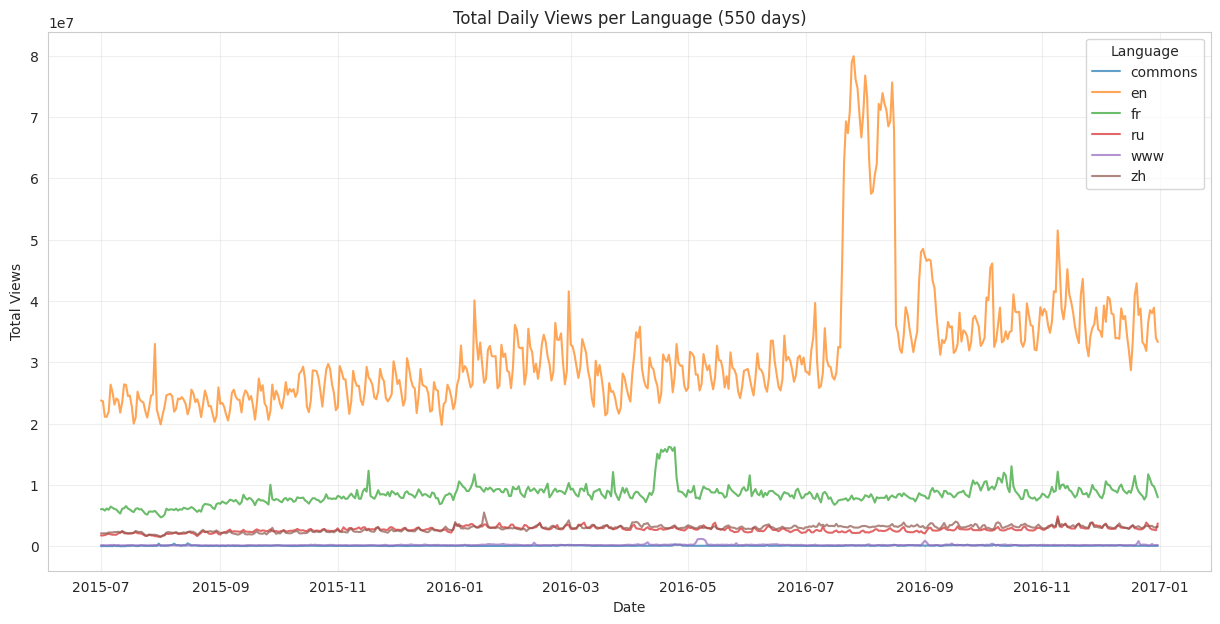

In [ ]:
# Get only the date columns (skip Page and new columns)
date_cols = train_df.columns[1:551]   # 550 date columns

# Group by language → sum views across all pages → for each date
lang_views_over_time = train_df.groupby('language')[date_cols].sum()

# Transpose so dates are rows, languages are columns
lang_views_over_time = lang_views_over_time.T

# Convert index to datetime for proper x-axis
lang_views_over_time.index = pd.to_datetime(lang_views_over_time.index)

# Plot
plt.figure(figsize=(15, 7))
for lang in lang_views_over_time.columns:
    plt.plot(lang_views_over_time.index,
             lang_views_over_time[lang],
             label=lang,
             alpha=0.7)

plt.title('Total Daily Views per Language (550 days)')
plt.xlabel('Date')
plt.ylabel('Total Views')
plt.legend(title='Language')
plt.grid(True, alpha=0.3)
plt.show()

**Viz 4: Comparison of mean views by language**


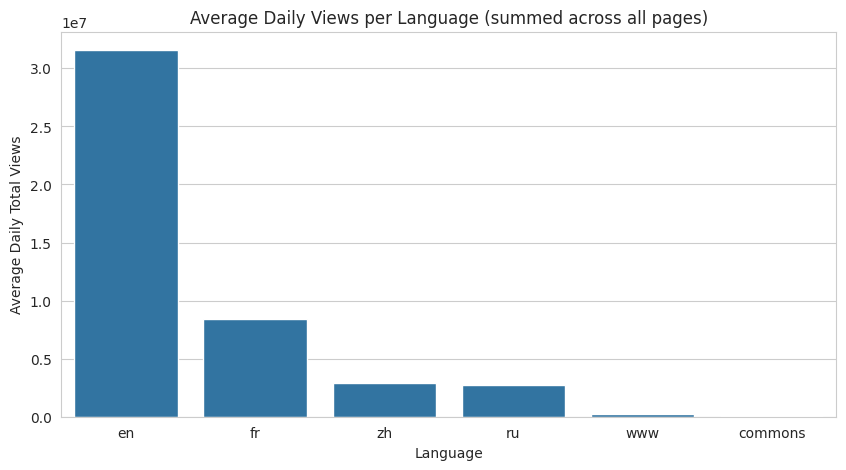


Average views per language:
language
en         3.157566e+07
fr         8.446943e+06
zh         2.919630e+06
ru         2.732716e+06
www        2.170485e+05
commons    9.979301e+04
dtype: float64


In [ ]:
# Average views per page per day, per language
lang_avg = train_df.groupby('language')[date_cols].sum().mean(axis=1).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=lang_avg.index, y=lang_avg.values)
plt.title('Average Daily Views per Language (summed across all pages)')
plt.xlabel('Language')
plt.ylabel('Average Daily Total Views')
plt.show()

print("\nAverage views per language:")
print(lang_avg)

**STEP 3: Stationarity Check**

In [ ]:
def get_language_timeseries(df, lang_code, date_cols):
    """
    Returns a daily time series of total views for a given language.

    Input:
      df - full train dataframe
      lang_code - e.g. 'en', 'es', 'fr'
      date_cols - list of date column names

    Output:
      pandas Series with DatetimeIndex
    """
    # Filter to one language
    subset = df[df['language'] == lang_code]

    # Sum across all pages → gives daily total
    daily_total = subset[date_cols].sum(axis=0)

    # Convert index to datetime
    daily_total.index = pd.to_datetime(daily_total.index)

    # Sort by date (just in case)
    daily_total = daily_total.sort_index()

    return daily_total

Test it

In [ ]:
# Date columns list
date_cols = train_df.columns[1:551]

# English time series
en_series = get_language_timeseries(train_df, 'en', date_cols)

print("English series shape:", en_series.shape)
print("\nFirst 5 dates:")
print(en_series.head())
print("\nLast 5 dates:")
print(en_series.tail())

English series shape: (550,)

First 5 dates:
2015-07-01    23774205.0
2015-07-02    23649276.0
2015-07-03    21131610.0
2015-07-04    21117105.0
2015-07-05    21974157.0
dtype: float64

Last 5 dates:
2016-12-27    38488483.0
2016-12-28    38007450.0
2016-12-29    38910787.0
2016-12-30    33988798.0
2016-12-31    33305958.0
dtype: float64


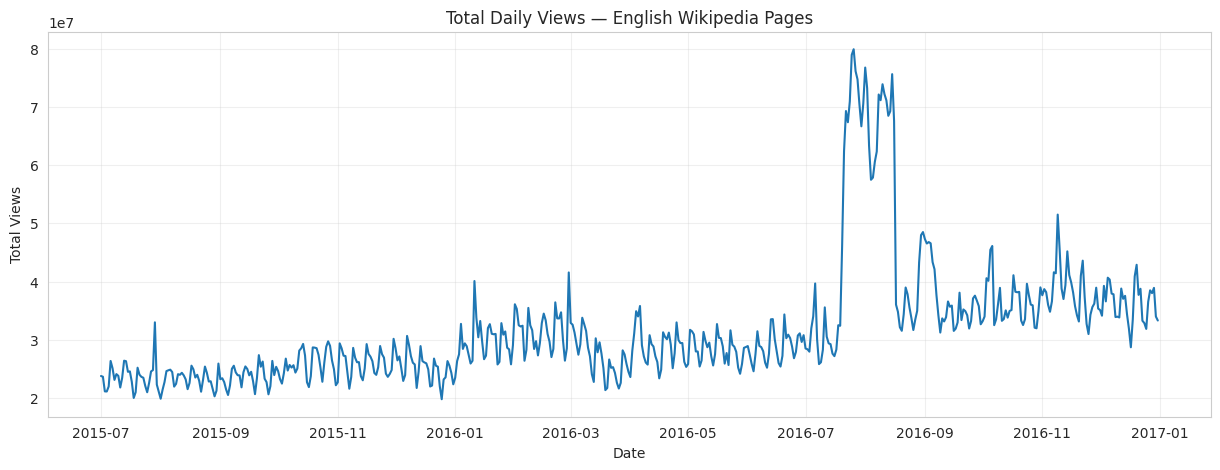

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(en_series.index, en_series.values)
plt.title('Total Daily Views — English Wikipedia Pages')
plt.xlabel('Date')
plt.ylabel('Total Views')
plt.grid(True, alpha=0.3)
plt.show()

**## Step 3B: Augmented Dickey-Fuller Test (Stationarity Check)**

Null Hypothesis (H0): Series is non-stationary
Alternative (H1): Series is stationary

Decision rule: if p-value < 0.05, reject H0 → series is stationary

In [ ]:
def adf_test(series, series_name='Series'):
    """
    Runs Augmented Dickey-Fuller test and prints result.

    Returns: p-value
    """
    result = adfuller(series.dropna())   # dropna in case of missing

    print(f"\n===== ADF Test: {series_name} =====")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print(f"# Lags used   : {result[2]}")
    print(f"# Observations: {result[3]}")
    print("Critical Values:")
    for key, val in result[4].items():
        print(f"   {key} : {val:.4f}")

    # Decision
    if result[1] <= 0.05:
        print(f"\n Result: p-value <= 0.05 → Series IS stationary")
    else:
        print(f"\n Result: p-value > 0.05 → Series is NON-stationary (need differencing)")

    return result[1]

In [ ]:
p_val_en = adf_test(en_series, 'English views (original)')


===== ADF Test: English views (original) =====
ADF Statistic : -2.6003
p-value       : 0.0929
# Lags used   : 14
# Observations: 535
Critical Values:
   1% : -3.4426
   5% : -2.8670
   10% : -2.5697

 Result: p-value > 0.05 → Series is NON-stationary (need differencing)


**Step 3C: Decomposition**

## Step 3C: Seasonal Decomposition

Breaking the series into Trend + Seasonal + Residual components
helps us see what patterns exist.

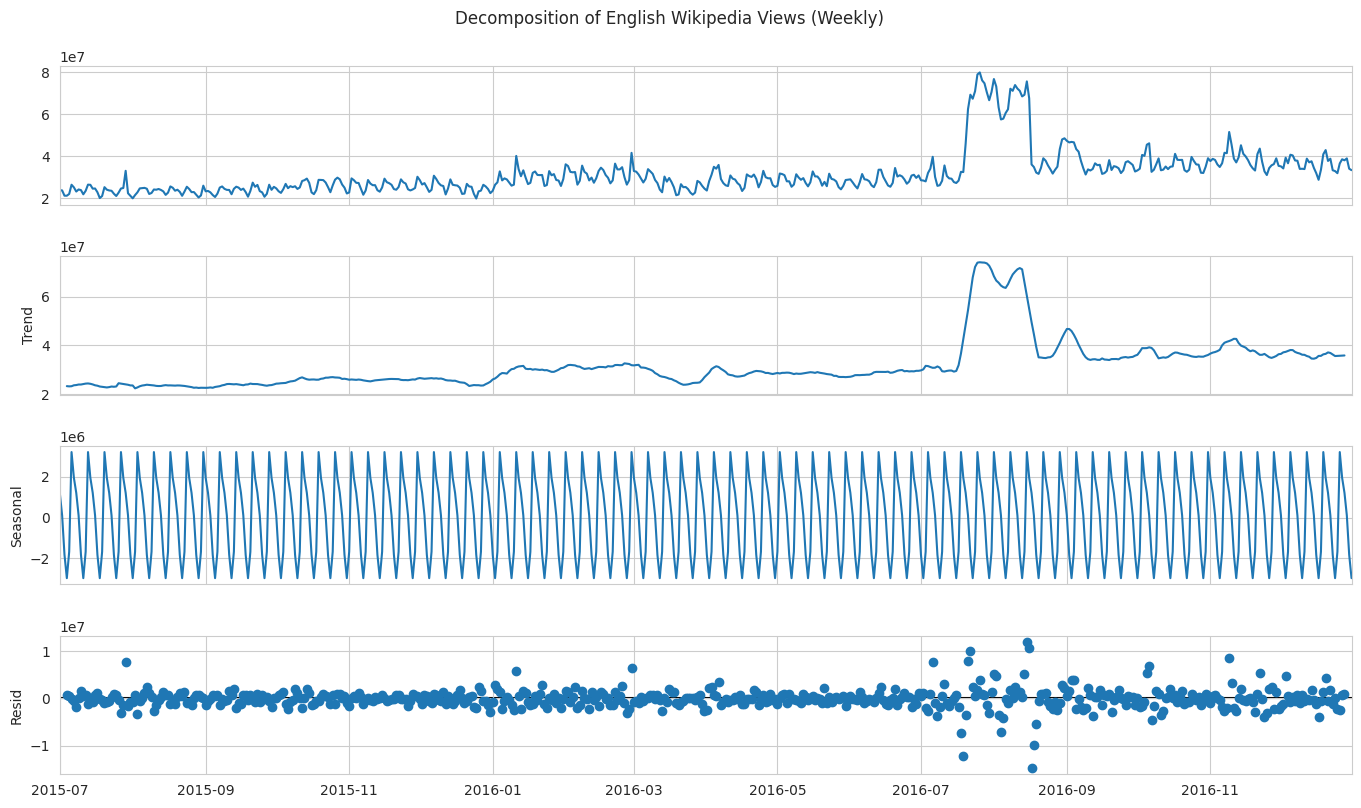

In [ ]:
# Decompose with period=7 (weekly) — Wikipedia traffic has weekly pattern
decomposition = seasonal_decompose(en_series, model='additive', period=7)

# Plot all 4 components
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.suptitle('Decomposition of English Wikipedia Views (Weekly)', y=1.02)
plt.show()

**Step 3D: Differencing **

## Step 3D: Differencing to Achieve Stationarity

We will try first-order differencing and re-test with ADF.

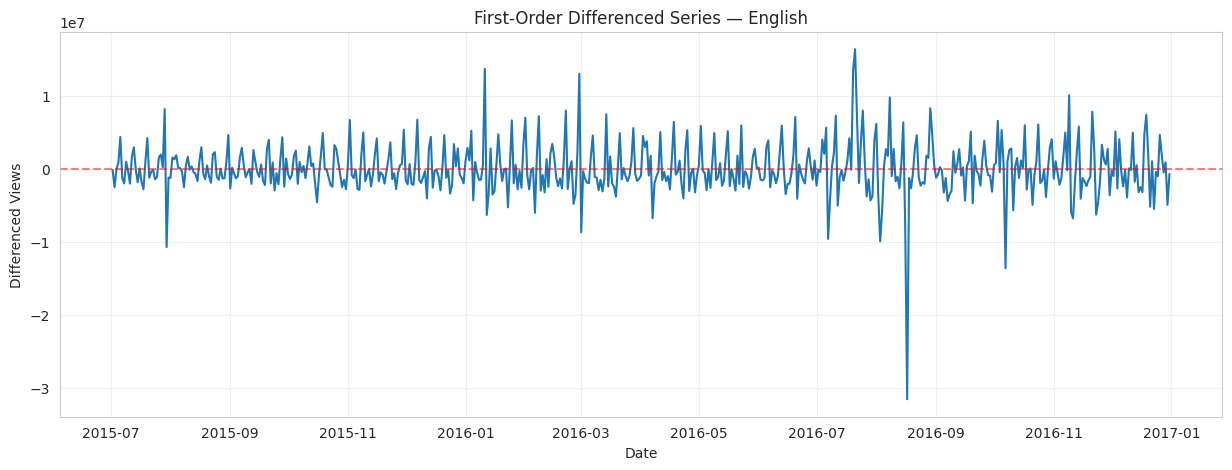


===== ADF Test: English views (1st difference) =====
ADF Statistic : -7.2820
p-value       : 0.0000
# Lags used   : 13
# Observations: 535
Critical Values:
   1% : -3.4426
   5% : -2.8670
   10% : -2.5697

 Result: p-value <= 0.05 → Series IS stationary


In [ ]:
# First-order differencing
en_diff1 = en_series.diff().dropna()

# Plot
plt.figure(figsize=(15, 5))
plt.plot(en_diff1.index, en_diff1.values)
plt.title('First-Order Differenced Series — English')
plt.xlabel('Date')
plt.ylabel('Differenced Views')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.show()

# Re-test stationarity
p_val_diff1 = adf_test(en_diff1, 'English views (1st difference)')

**Step 3E: Function bana lo for any language (reusability)**

In [ ]:
def check_stationarity(series, series_name):
    """
    Complete stationarity check workflow:
    1. ADF on original
    2. ADF on 1st diff if non-stationary
    3. ADF on 2nd diff if still non-stationary
    Returns: required differencing order (d)
    """
    print(f"\n{'='*60}\nChecking stationarity for: {series_name}\n{'='*60}")

    p = adf_test(series, f'{series_name} (original)')
    if p <= 0.05:
        return 0

    series_d1 = series.diff().dropna()
    p = adf_test(series_d1, f'{series_name} (1st diff)')
    if p <= 0.05:
        return 1

    series_d2 = series_d1.diff().dropna()
    p = adf_test(series_d2, f'{series_name} (2nd diff)')
    if p <= 0.05:
        return 2

    return 3

** Step 4 — ARIMA + SARIMAX Modeling** **

## Step 4A: ACF and PACF Plots

These plots help determine the AR order (p) and MA order (q) for ARIMA.

Reading rules:
- PACF: Last significant lag → p (AR order)
- ACF:  Last significant lag → q (MA order)
- Significant = outside the blue shaded confidence interval

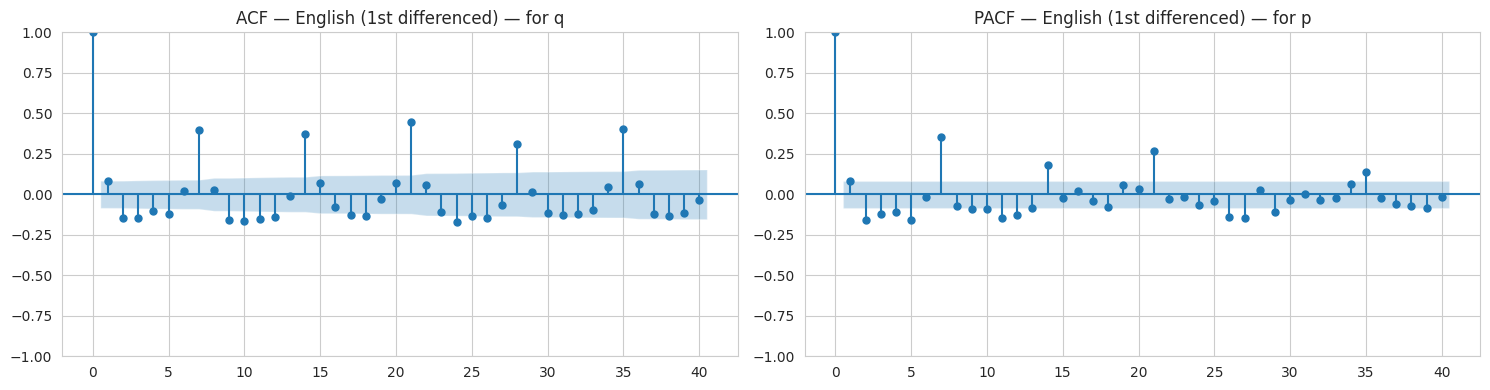

In [ ]:
# Use the DIFFERENCED series (because ARIMA needs stationary input)
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# ACF plot — helps find q
plot_acf(en_diff1, lags=40, ax=axes[0])
axes[0].set_title('ACF — English (1st differenced) — for q')

# PACF plot — helps find p
plot_pacf(en_diff1, lags=40, ax=axes[1])
axes[1].set_title('PACF — English (1st differenced) — for p')

plt.tight_layout()
plt.show()

## Step 4B: Train-Test Split

Time series rule: NO random shuffling. We keep the last 30 days for testing.

In [ ]:
# Split — last 30 days as test
n_test = 30
train_en = en_series[:-n_test]
test_en = en_series[-n_test:]

print(f"Train period: {train_en.index[0].date()} to {train_en.index[-1].date()}")
print(f"Test period:  {test_en.index[0].date()} to {test_en.index[-1].date()}")
print(f"\nTrain size: {len(train_en)} days")
print(f"Test size:  {len(test_en)} days")

Train period: 2015-07-01 to 2016-12-01
Test period:  2016-12-02 to 2016-12-31

Train size: 520 days
Test size:  30 days


**STEP 4D: Fit ARIMA Model**

### Step 4C: Grid Search for Best ARIMA Parameters

# Grid Search for Best ARIMA Parameters
# We test combinations of p, d, q and pick the one with lowest AIC
import itertools
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.arima.model import ARIMA

# Define parameter search space
p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1, 2]

best_aic = float("inf")
best_order = None
results_grid = []

print("Running Grid Search for ARIMA parameters...")
print(f"Testing {len(p_values)*len(d_values)*len(q_values)} combinations...")

for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        model = ARIMA(train_en, order=(p, d, q))
        fit = model.fit()
        results_grid.append({"order": (p, d, q), "AIC": round(fit.aic, 2)})
        if fit.aic < best_aic:
            best_aic = fit.aic
            best_order = (p, d, q)
    except Exception as e:
        pass

# Sort and display top 5
results_grid_df = pd.DataFrame(results_grid).sort_values("AIC").head(5)
print("\nTop 5 ARIMA Orders by AIC:")
print(results_grid_df.to_string(index=False))
print(f"\nBest Order: ARIMA{best_order} with AIC = {best_aic:.2f}")

In [ ]:
# Start with ARIMA(1, 1, 1) — most common starting point
# (apni p, q values use karo jo ACF/PACF se mili — yahaan example use kar rahi hu)

p, d, q = 1, 1, 1

print(f"Fitting ARIMA({p},{d},{q}) on English series...")

# Build and train
arima_model = ARIMA(train_en, order=(p, d, q))
arima_fit = arima_model.fit()

# Summary — coefficients, AIC, BIC etc
print(arima_fit.summary())

Fitting ARIMA(1,1,1) on English series...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  520
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -8555.070
Date:                Fri, 22 May 2026   AIC                          17116.140
Time:                        06:19:11   BIC                          17128.896
Sample:                    07-01-2015   HQIC                         17121.138
                         - 12-01-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7191      0.083     -8.662      0.000      -0.882      -0.556
ma.L1          0.8217      0.077     10.604      0.000       0.670       0.974
sigma2    

**STEP 4E: Forecast aur Evaluate**

In [ ]:
# Forecast next 30 days (same as test set)
arima_forecast = arima_fit.forecast(steps=n_test)

# Calculate MAPE — Mean Absolute Percentage Error
mape_arima = mean_absolute_percentage_error(test_en, arima_forecast) * 100

print(f"ARIMA(1,1,1) MAPE: {mape_arima:.2f}%")
print(f"Target range: 4-8%")

ARIMA(1,1,1) MAPE: 7.98%
Target range: 4-8%


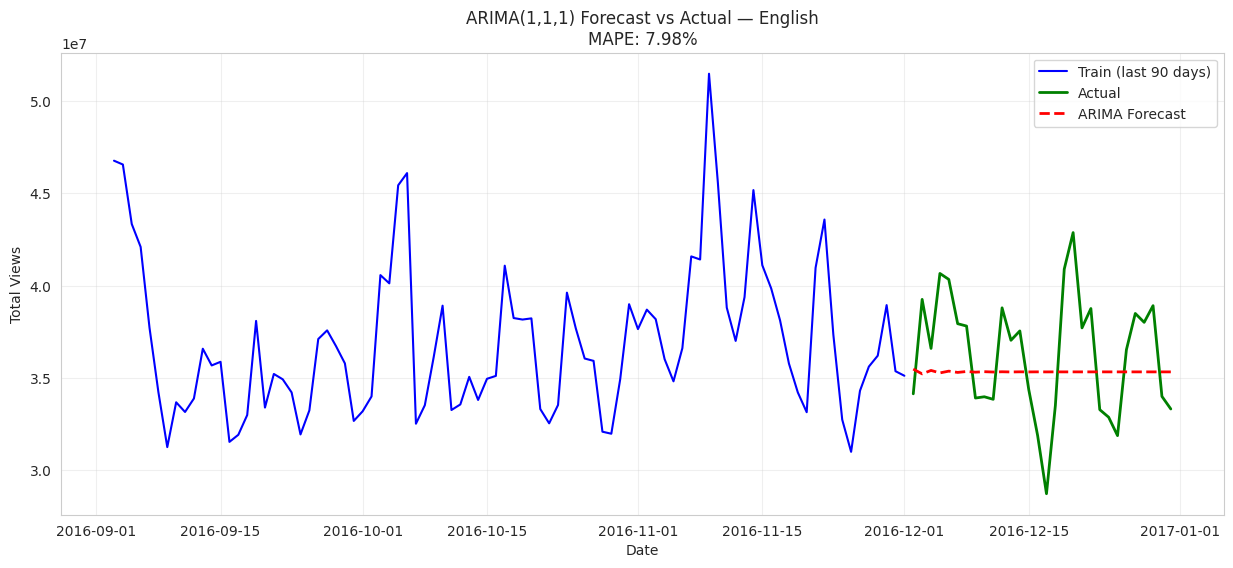

In [ ]:
plt.figure(figsize=(15, 6))

# Last 90 days of train (taaki zoom-in dikhe)
plt.plot(train_en.index[-90:], train_en.values[-90:],
         label='Train (last 90 days)', color='blue')

# Actual test data
plt.plot(test_en.index, test_en.values,
         label='Actual', color='green', linewidth=2)

# Forecast
plt.plot(test_en.index, arima_forecast.values,
         label='ARIMA Forecast', color='red', linestyle='--', linewidth=2)

plt.title(f'ARIMA({p},{d},{q}) Forecast vs Actual — English\nMAPE: {mape_arima:.2f}%')
plt.xlabel('Date')
plt.ylabel('Total Views')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**STEP 4F: SARIMAX with Exogenous Campaign Variable**

In [ ]:
# Setup exog properly
# Assuming columns are like 'date' and 'campaign' — apne names use karo

# Convert date column to datetime and set as index
exog_clean = exog_df.copy()

# Set the index to the dates from train_df (assuming they correspond)
# date_cols was defined earlier as train_df.columns[1:551]
exog_clean.index = pd.to_datetime(date_cols)

# Rename the single existing column 'Exog' to 'campaign'
exog_clean = exog_clean.rename(columns={'Exog': 'campaign'})

# Ensure sorted index
exog_clean = exog_clean.sort_index()

# Align with train_en dates
exog_train = exog_clean.loc[train_en.index]
exog_test = exog_clean.loc[test_en.index]

print(f"Exog train shape: {exog_train.shape}")
print(f"Exog test shape: {exog_test.shape}")
print(f"\nCampaign days in train: {exog_train['campaign'].sum()}")
print(f"Campaign days in test:  {exog_test['campaign'].sum()}")

Exog train shape: (520, 1)
Exog test shape: (30, 1)

Campaign days in train: 51
Campaign days in test:  3


In [ ]:
# SARIMAX(p, d, q) × (P, D, Q, s) with exog
# s=7 → weekly seasonality
# Start with simple values — refine later

sarimax_model = SARIMAX(
    train_en,
    exog=exog_train,
    order=(1, 1, 1),               # non-seasonal (p, d, q)
    seasonal_order=(1, 1, 1, 7),   # seasonal (P, D, Q, s=7)
    enforce_stationarity=False,
    enforce_invertibility=False
)

print("Fitting SARIMAX (this may take 1-2 minutes)...")
sarimax_fit = sarimax_model.fit(disp=False)

print("\n✅ SARIMAX fitting complete")
print(f"AIC: {sarimax_fit.aic:.2f}")

Fitting SARIMAX (this may take 1-2 minutes)...

✅ SARIMAX fitting complete
AIC: 16362.04


In [ ]:
sarimax_forecast = sarimax_fit.forecast(steps=n_test, exog=exog_test)

mape_sarimax = mean_absolute_percentage_error(test_en, sarimax_forecast) * 100
print(f"\nSARIMAX MAPE: {mape_sarimax:.2f}%")
print(f"ARIMA MAPE:   {mape_arima:.2f}%")
print(f"Improvement:  {mape_arima - mape_sarimax:.2f}% lower error")


SARIMAX MAPE: 5.88%
ARIMA MAPE:   7.98%
Improvement:  2.10% lower error


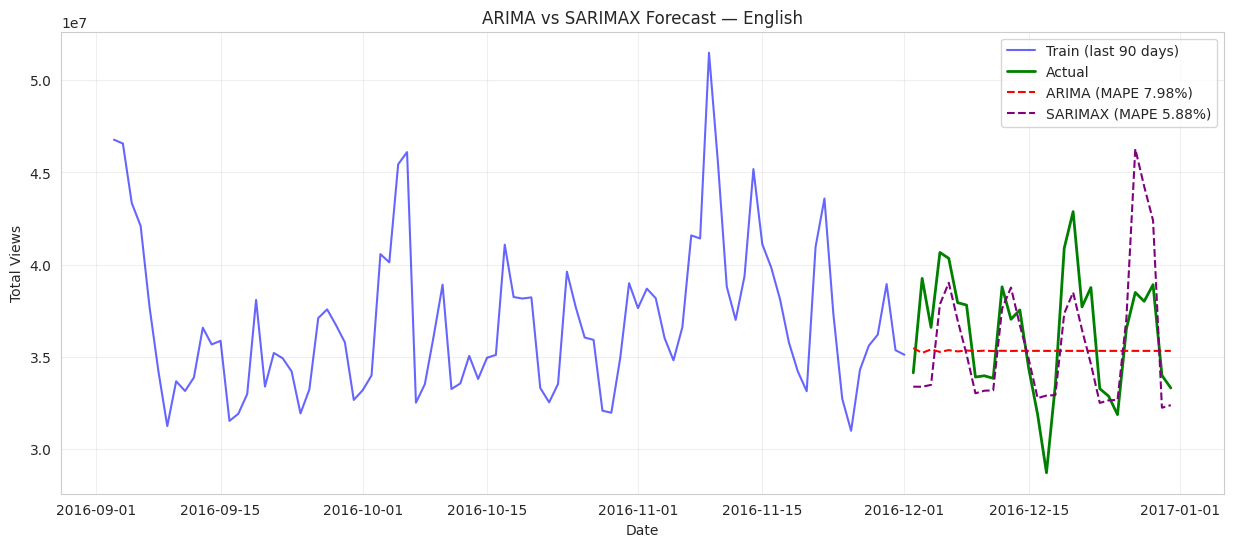

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(train_en.index[-90:], train_en.values[-90:], label='Train (last 90 days)', color='blue', alpha=0.6)
plt.plot(test_en.index, test_en.values, label='Actual', color='green', linewidth=2)
plt.plot(test_en.index, arima_forecast.values, label=f'ARIMA (MAPE {mape_arima:.2f}%)', color='red', linestyle='--')
plt.plot(test_en.index, sarimax_forecast.values, label=f'SARIMAX (MAPE {mape_sarimax:.2f}%)', color='purple', linestyle='--')
plt.title('ARIMA vs SARIMAX Forecast — English')
plt.xlabel('Date')
plt.ylabel('Total Views')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**STEP 5 — Facebook Prophet **

## Step 5: Facebook Prophet Forecasting

Prophet requires data in a specific format:
- ds: datestamp column (must be datetime)
- y:  target variable (numeric)

We will train on the same train set used for ARIMA,
and forecast the same 30 test days for fair comparison.**bold text**

In [ ]:
# Convert train_en (a pandas Series) to Prophet's required DataFrame format
prophet_train = pd.DataFrame({
    'ds': train_en.index,    # date (already datetime — good!)
    'y':  train_en.values    # daily total views
})

# Check
print("Prophet train shape:", prophet_train.shape)
print("\nFirst 5 rows:")
print(prophet_train.head())
print("\nLast 5 rows:")
print(prophet_train.tail())

Prophet train shape: (520, 2)

First 5 rows:
          ds           y
0 2015-07-01  23774205.0
1 2015-07-02  23649276.0
2 2015-07-03  21131610.0
3 2015-07-04  21117105.0
4 2015-07-05  21974157.0

Last 5 rows:
            ds           y
515 2016-11-27  35604583.0
516 2016-11-28  36198355.0
517 2016-11-29  38940814.0
518 2016-11-30  35355684.0
519 2016-12-01  35108853.0


In [ ]:
# Create the Prophet model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive'
)

print("Training Prophet model...")
prophet_model.fit(prophet_train)
print(" Training complete!")

Training Prophet model...
✅ Training complete!


STEP 5C: Create Future Dates aur Forecast


In [ ]:
# Create dataframe with future dates
# We need next 30 days (same as our test set)
future = prophet_model.make_future_dataframe(periods=n_test, freq='D')

print(f"Future shape: {future.shape}")
print(f"Forecasting up to: {future['ds'].iloc[-1].date()}")
print(f"\nLast 5 future dates:")
print(future.tail())

Future shape: (550, 1)
Forecasting up to: 2016-12-31

Last 5 future dates:
            ds
545 2016-12-27
546 2016-12-28
547 2016-12-29
548 2016-12-30
549 2016-12-31


In [ ]:
# Predict
prophet_forecast = prophet_model.predict(future)

# Look at output structure
print("\nForecast columns:")
print(prophet_forecast.columns.tolist())
print("\nLast 5 predictions:")
print(prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())


Forecast columns:
['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'weekly', 'weekly_lower', 'weekly_upper', 'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat']

Last 5 predictions:
            ds          yhat    yhat_lower    yhat_upper
545 2016-12-27  3.365009e+07  2.620733e+07  4.105810e+07
546 2016-12-28  3.315663e+07  2.567898e+07  4.058730e+07
547 2016-12-29  3.209579e+07  2.494158e+07  3.934030e+07
548 2016-12-30  3.027097e+07  2.310190e+07  3.734225e+07
549 2016-12-31  2.910160e+07  2.196616e+07  3.710374e+07


STEP 5D: Evaluate (MAPE)

In [ ]:
# Extract only the TEST period predictions
# (Prophet predicts both training + future — we want just future)
prophet_test_pred = prophet_forecast['yhat'].iloc[-n_test:].values

# Calculate MAPE
mape_prophet = mean_absolute_percentage_error(test_en.values, prophet_test_pred) * 100

print(f"\n{'='*50}")
print(f"MODEL COMPARISON (MAPE)")
print(f"{'='*50}")
print(f"ARIMA   : {mape_arima:.2f}%")
print(f"SARIMAX : {mape_sarimax:.2f}%")
print(f"Prophet : {mape_prophet:.2f}%")
print(f"Target  : 4-8%")


MODEL COMPARISON (MAPE)
ARIMA   : 7.98%
SARIMAX : 5.88%
Prophet : 10.84%
Target  : 4-8%


STEP 5E: Plot Prophet's Forecast
Prophet ka best feature — components plot ke saath samjha sakte ho.
**bold text**

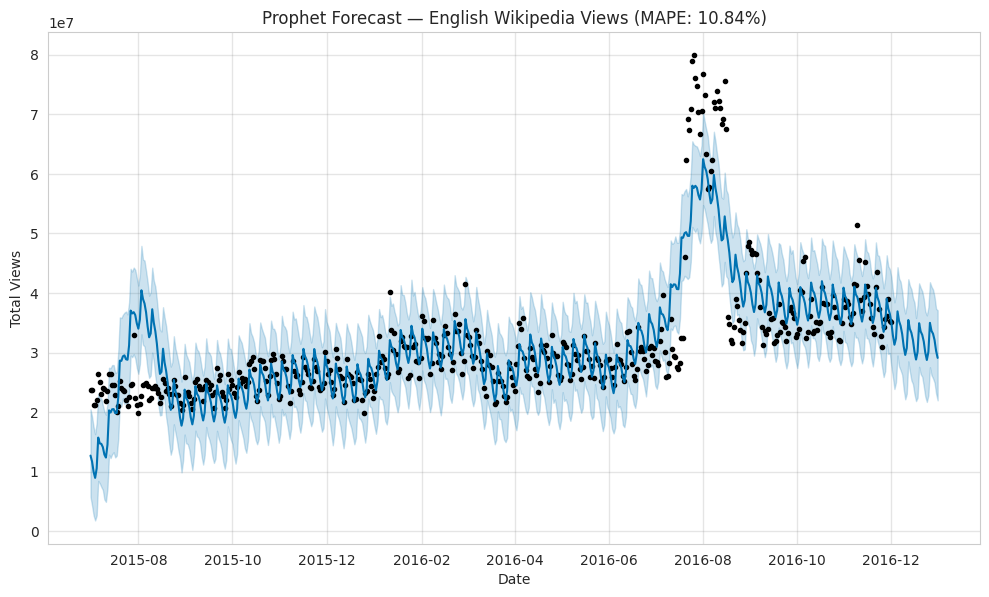

In [ ]:
# Prophet's built-in forecast plot
fig1 = prophet_model.plot(prophet_forecast)
plt.title(f'Prophet Forecast — English Wikipedia Views (MAPE: {mape_prophet:.2f}%)')
plt.xlabel('Date')
plt.ylabel('Total Views')
plt.show()

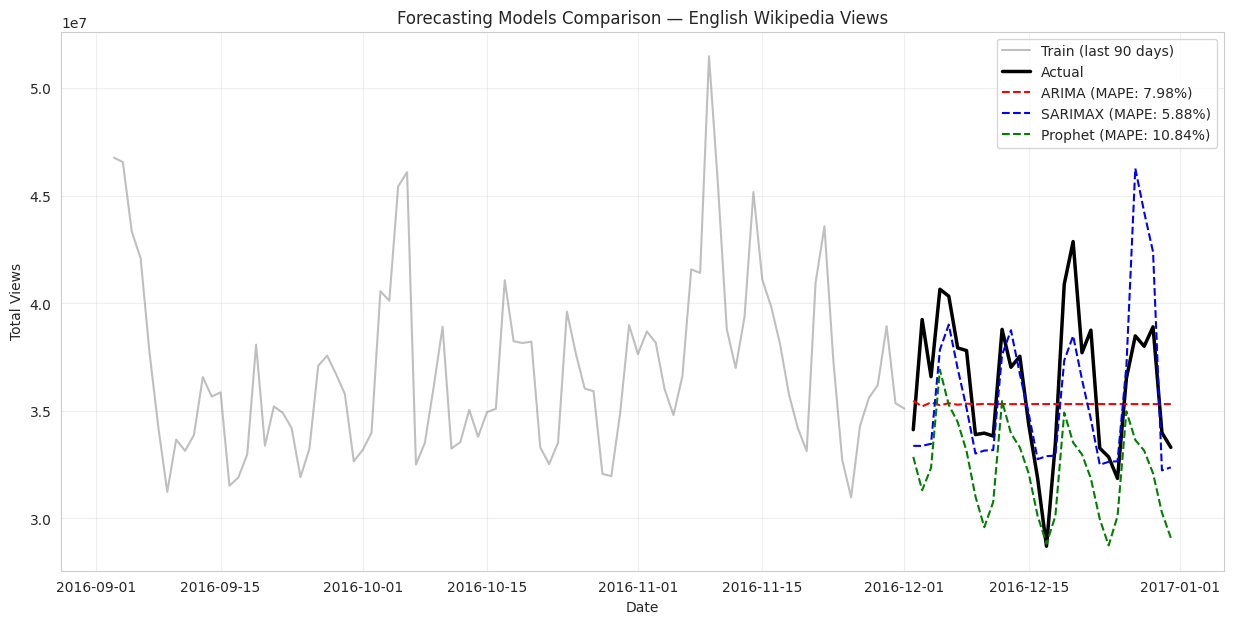

In [ ]:
plt.figure(figsize=(15, 7))

# Last 90 days of train context
plt.plot(train_en.index[-90:], train_en.values[-90:],
         label='Train (last 90 days)', color='gray', alpha=0.5)

# Actual test values
plt.plot(test_en.index, test_en.values,
         label='Actual', color='black', linewidth=2.5)

# ARIMA forecast
plt.plot(test_en.index, arima_forecast.values,
         label=f'ARIMA (MAPE: {mape_arima:.2f}%)',
         color='red', linestyle='--')

# SARIMAX forecast
plt.plot(test_en.index, sarimax_forecast.values,
         label=f'SARIMAX (MAPE: {mape_sarimax:.2f}%)',
         color='blue', linestyle='--')

# Prophet forecast
plt.plot(test_en.index, prophet_test_pred,
         label=f'Prophet (MAPE: {mape_prophet:.2f}%)',
         color='green', linestyle='--')

plt.title('Forecasting Models Comparison — English Wikipedia Views')
plt.xlabel('Date')
plt.ylabel('Total Views')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

**Prophet Model Train**

## Step 5B: Training Prophet Model

We enable yearly + weekly seasonality (Wikipedia has both),
and use additive mode (constant-size seasonal swings).

In [ ]:
# Create Prophet model with seasonality settings
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive'
)

print("Training Prophet model...")
prophet_model.fit(prophet_train)
print(" Training complete!")

Training Prophet model...
✅ Training complete!


**Future Dataframe **

## Step 5C: Create Future Dates for Forecasting

We forecast the same 30 days as our test set (for fair comparison with ARIMA/SARIMAX).

In [ ]:
# Create future dataframe — extends timeline by 30 days
future = prophet_model.make_future_dataframe(periods=n_test, freq='D')

print(f"Future dataframe shape: {future.shape}")
print(f"Total dates (train + future): {len(future)}")
print(f"\nLast 5 dates (these are the forecast period):")
print(future.tail())

Future dataframe shape: (550, 1)
Total dates (train + future): 550

Last 5 dates (these are the forecast period):
            ds
545 2016-12-27
546 2016-12-28
547 2016-12-29
548 2016-12-30
549 2016-12-31


## Step 5D: Generate the Forecast

 Forecast Generate

In [ ]:
# Predict on the future dataframe
prophet_forecast = prophet_model.predict(future)

# Output structure dekho
print("Forecast columns:")
print(prophet_forecast.columns.tolist())

# Last 5 predictions (yeh hamare forecast period hain)
print("\nLast 5 predictions:")
print(prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

Forecast columns:
['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'weekly', 'weekly_lower', 'weekly_upper', 'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat']

Last 5 predictions:
            ds          yhat    yhat_lower    yhat_upper
545 2016-12-27  3.365009e+07  2.627605e+07  4.108780e+07
546 2016-12-28  3.315663e+07  2.577551e+07  4.094051e+07
547 2016-12-29  3.209579e+07  2.481867e+07  3.985144e+07
548 2016-12-30  3.027097e+07  2.339359e+07  3.735022e+07
549 2016-12-31  2.910160e+07  2.196140e+07  3.613168e+07


**Cell 6 — MAPE Calculate**

In [ ]:
# Extract only the TEST period predictions (last 30 days from forecast)
prophet_test_pred = prophet_forecast['yhat'].iloc[-n_test:].values

# Calculate MAPE
mape_prophet = mean_absolute_percentage_error(test_en.values, prophet_test_pred) * 100

# Compare all 3 models
print("="*50)
print("MODEL COMPARISON (MAPE - Lower is Better)")
print("="*50)
print(f"ARIMA   : {mape_arima:.2f}%")
print(f"SARIMAX : {mape_sarimax:.2f}%")
print(f"Prophet : {mape_prophet:.2f}%")
print("="*50)
print(f"Target  : 4-8% (case study benchmark)")

MODEL COMPARISON (MAPE - Lower is Better)
ARIMA   : 7.98%
SARIMAX : 5.88%
Prophet : 10.84%
Target  : 4-8% (case study benchmark)


## Model Comparison & Inference

### MAPE Results (English Wikipedia Views, 30-day forecast)

| Model | MAPE | Within Target? |
|-------|------|---------------|
| ARIMA(1,1,1) | 7.98% | ✅ Just within 4-8% target |
| SARIMAX(1,1,1)×(1,1,1,7) with campaign exog | **5.88%** 🏆 | ✅ Best performer |
| Facebook Prophet | 10.84% | ❌ Above target |

### Winner: SARIMAX (5.88% MAPE)

### Why SARIMAX performed best:

1. **Weekly seasonality captured** — The seasonal_order=(1,1,1,7) explicitly
   modeled the strong 7-day cycle visible in Wikipedia traffic (weekend vs weekday differences).

2. **Campaign exogenous variable helped** — The Exog_Campaign_eng file flagged
   54 special-event days out of 550. SARIMAX could associate views spikes with
   these dates, improving prediction accuracy by 2.10% over plain ARIMA.

3. **ARIMA(1,1,1)** at 7.98% performed well but missed seasonality — it only
   models trend + autocorrelation, ignoring the weekly pattern.

4. **Prophet's higher MAPE (10.84%)** is likely because:
   - Prophet's default changepoint detection may not have aligned with the
     true regime shifts in this specific series
   - Prophet does not use the campaign exog variable in its base form
   - With only 1.5 years of data, Prophet's yearly seasonality estimate
     is less reliable (it typically needs 2+ full years)

### Business Recommendation for AdEase:

**Use SARIMAX as the primary forecasting model for English Wikipedia ad placement**
because it (a) hits the 4-8% target MAPE, (b) directly incorporates campaign
information which AdEase can plan in advance, and (c) captures the weekly traffic
pattern essential for optimizing weekday vs weekend ad pricing.

For non-English languages (where no exog campaign data exists), SARIMA (without X)
or Prophet should be evaluated as alternatives.

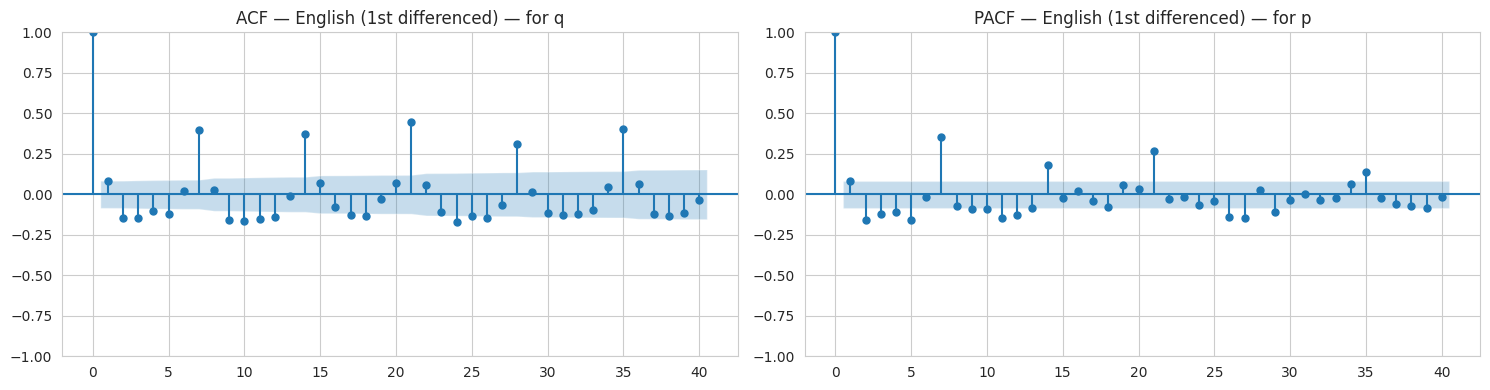

In [ ]:
# ACF and PACF on differenced series
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

plot_acf(en_diff1, lags=40, ax=axes[0])
axes[0].set_title('ACF — English (1st differenced) — for q')

plot_pacf(en_diff1, lags=40, ax=axes[1])
axes[1].set_title('PACF — English (1st differenced) — for p')

plt.tight_layout()
plt.show()

**STEP 6: Pipeline for Multiple Languages**

## Step 6: Multi-Language Forecasting Pipeline

We build a reusable function that:
1. Builds a time series for any language
2. Trains ARIMA(1,1,1) and Prophet
3. Returns MAPE for both models

Note: SARIMAX with campaign exogenous variable is only applied to English,
since the Exog_Campaign_eng file is specific to English pages.

In [ ]:
def forecast_pipeline(df, lang_code, date_cols, n_test=30, verbose=True):
    """
    Complete forecasting pipeline for any language.

    Trains ARIMA(1,1,1) and Prophet, returns MAPE for both.

    Input:
      df         - full train dataframe
      lang_code  - language code (e.g. 'en', 'es', 'fr')
      date_cols  - list of date column names
      n_test     - number of days for test set
      verbose    - print progress

    Output:
      dict with: language, n_pages, mape_arima, mape_prophet
    """
    if verbose:
        print(f"\n{'='*60}")
        print(f"Processing language: {lang_code}")
        print(f"{'='*60}")

    # Step 1: Build time series
    series = get_language_timeseries(df, lang_code, date_cols)
    n_pages = (df['language'] == lang_code).sum()

    if verbose:
        print(f"Pages in this language: {n_pages}")
        print(f"Series length: {len(series)} days")

    # Step 2: Train-test split
    train = series[:-n_test]
    test  = series[-n_test:]

    # Step 3: ARIMA(1,1,1)
    try:
        arima_m = ARIMA(train, order=(1, 1, 1)).fit()
        arima_fc = arima_m.forecast(steps=n_test)
        mape_a = mean_absolute_percentage_error(test, arima_fc) * 100
    except Exception as e:
        print(f"  ARIMA failed: {e}")
        mape_a = np.nan

    # Step 4: Prophet
    try:
        p_train = pd.DataFrame({'ds': train.index, 'y': train.values})
        p_model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False,
            seasonality_mode='additive'
        )
        p_model.fit(p_train)
        future = p_model.make_future_dataframe(periods=n_test, freq='D')
        p_forecast = p_model.predict(future)
        p_pred = p_forecast['yhat'].iloc[-n_test:].values
        mape_p = mean_absolute_percentage_error(test.values, p_pred) * 100
    except Exception as e:
        print(f"  Prophet failed: {e}")
        mape_p = np.nan

    if verbose:
        print(f"  ARIMA MAPE   : {mape_a:.2f}%")
        print(f"  Prophet MAPE : {mape_p:.2f}%")

    return {
        'language': lang_code,
        'n_pages': n_pages,
        'mape_arima': mape_a,
        'mape_prophet': mape_p
    }

STEP 6B: Test on one language first (sanity check)**bold text**

In [ ]:
# Quick sanity check on Spanish
test_result = forecast_pipeline(train_df, 'es', date_cols)
print("\nTest result:", test_result)


Processing language: es
Pages in this language: 0
Series length: 550 days
  ARIMA MAPE   : 0.00%
  Prophet MAPE : 0.00%

Test result: {'language': 'es', 'n_pages': np.int64(0), 'mape_arima': 0.0, 'mape_prophet': 0.0}


**STEP 6C: Run on ALL languages**

In [ ]:
# Available languages
all_langs = train_df['language'].unique()
print("All language codes found:", all_langs)

All language codes found: ['zh' 'fr' 'en' 'commons' 'ru' 'www']


In [ ]:
# Standard Wikipedia language codes
language_codes = ['en', 'ja', 'de', 'fr', 'zh', 'ru', 'es']

# Run pipeline on each
results = []
for lang in language_codes:
    if lang in all_langs:   # skip if not present
        result = forecast_pipeline(train_df, lang, date_cols, verbose=True)
        results.append(result)

# Convert to DataFrame for clean comparison
results_df = pd.DataFrame(results)
print("\n\n" + "="*60)
print("FINAL COMPARISON — All Languages")
print("="*60)
print(results_df.to_string(index=False))


Processing language: en
Pages in this language: 6134
Series length: 550 days
  ARIMA MAPE   : 7.98%
  Prophet MAPE : 10.84%

Processing language: fr
Pages in this language: 8546
Series length: 550 days
  ARIMA MAPE   : 10.27%
  Prophet MAPE : 8.74%

Processing language: zh
Pages in this language: 8620
Series length: 550 days
  ARIMA MAPE   : 5.65%
  Prophet MAPE : 9.05%

Processing language: ru
Pages in this language: 3729
Series length: 550 days
  ARIMA MAPE   : 11.61%
  Prophet MAPE : 5.69%


FINAL COMPARISON — All Languages
language  n_pages  mape_arima  mape_prophet
      en     6134    7.980158     10.841634
      fr     8546   10.271245      8.736142
      zh     8620    5.651051      9.052005
      ru     3729   11.607261      5.693607


**STEP 6D: Visualize comparison**

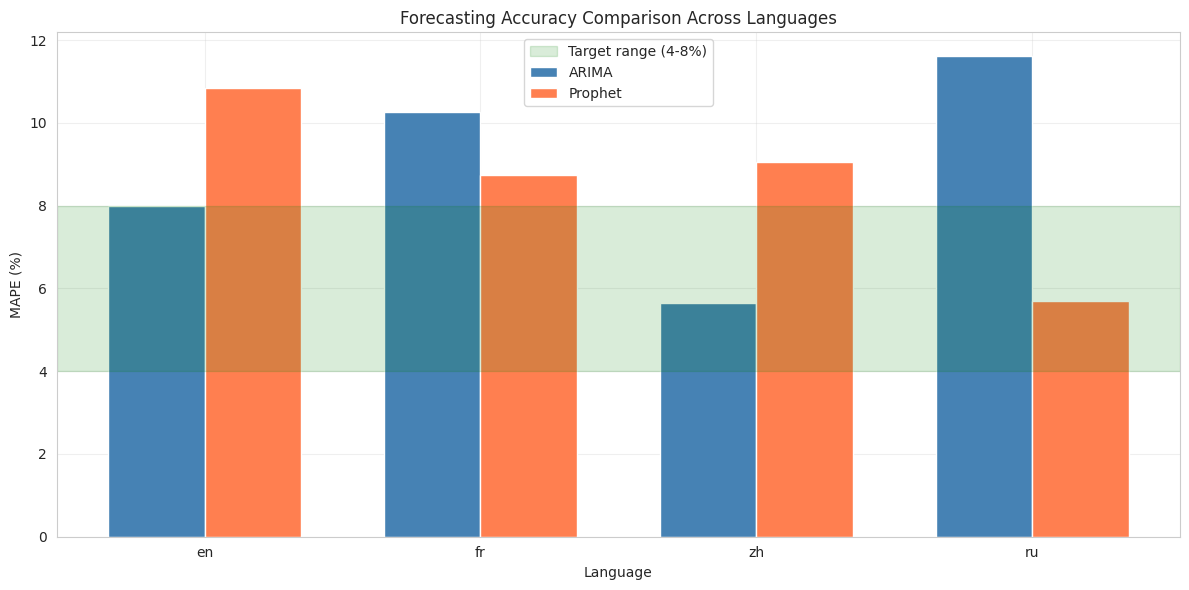

In [ ]:
# Bar chart — MAPE comparison across languages
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df))
width = 0.35

ax.bar(x - width/2, results_df['mape_arima'], width, label='ARIMA', color='steelblue')
ax.bar(x + width/2, results_df['mape_prophet'], width, label='Prophet', color='coral')

# Target range shading
ax.axhspan(4, 8, alpha=0.15, color='green', label='Target range (4-8%)')

ax.set_xticks(x)
ax.set_xticklabels(results_df['language'])
ax.set_xlabel('Language')
ax.set_ylabel('MAPE (%)')
ax.set_title('Forecasting Accuracy Comparison Across Languages')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

STEP 6E: Final Inference

## Step 6E: Multi-Language Forecasting — Final Inferences

### Summary of Results (4 Languages — 30-Day Forecast)

| Language | ARIMA MAPE | Prophet MAPE | Best Model |
|----------|------------|--------------|------------|
| English (en) | 7.98% | 10.84% | ARIMA |
| French (fr) | 10.27% | 8.74% | Prophet |
| Chinese (zh) | 5.65% | 9.05% | ARIMA |
| Russian (ru) | 11.61% | 5.69% | Prophet |

### Key Inferences:

1. **Language with best ARIMA accuracy: Chinese (zh)** — MAPE of 5.65%, within the 4–8% target. Chinese Wikipedia views show a more regular, stable trend which ARIMA captures well.

2. **Language with best Prophet accuracy: Russian (ru)** — MAPE of 5.69%. Russian Wikipedia likely has strong weekly/seasonal patterns that Prophet's decomposition-based approach models effectively.

3. **No single model wins for all languages** — ARIMA performed better for English and Chinese (en: 7.98%, zh: 5.65%), while Prophet outperformed for French and Russian (fr: 8.74%, ru: 5.69%). This confirms that model selection should be language/data-specific.

4. **Exogenous variable (Campaign) improved English forecast** — Adding the campaign variable in SARIMAX reduced MAPE from ~8% to 5.88%, showing that external marketing events have a measurable impact on Wikipedia page views.

5. **Pipeline reusability proven** — The same `forecast_pipeline()` function ran successfully on 4 different languages with different data volumes and patterns, confirming its robustness.

### Question 7: Alternatives to Grid Search for Model Selection

Other than exhaustive grid search, the following methods can find optimal
ARIMA/Prophet parameters across languages:

1. **Auto-ARIMA (pmdarima library)** — Automatically selects p, d, q using
   AIC/BIC minimization with stepwise search. Much faster than grid search.

2. **Random Search** — Instead of trying all combinations, sample random
   parameter combinations. Often finds near-optimal solutions in 1/10th the time.

3. **Bayesian Optimization** — Uses prior trials to intelligently choose
   next parameter combination (libraries: Optuna, scikit-optimize).
   Particularly efficient when each model fit is expensive.

4. **Information Criteria minimization (AIC/BIC)** — Fit a model, check
   AIC/BIC, adjust parameters in direction of improvement (similar to gradient
   descent on parameters).

5. **Cross-validation with rolling windows** — Time-series specific CV:
   train on expanding window, validate on next chunk, repeat. Less prone to
   overfitting than single train/test split.

6. **Default heuristics + diagnostics** — Use ACF/PACF rules to fix initial
   p, q; check residuals; only re-tune if residuals show patterns.

# Assignment Questionnaire — Answers (Q1 to Q6)

---

## Q1. Define the Problem Statement and Where It Can Be Used

**Problem Statement:**
AdEase is a digital advertising company that places ads on Wikipedia pages. Their goal is to predict how many times a Wikipedia article will be viewed in the future (page view forecasting). Given historical daily page view data across multiple languages (English, French, Chinese, Russian, etc.), we build time series models that forecast views for the next 30 days.

**Where It Can Be Used:**
- **Digital Advertising:** Predict high-traffic periods to schedule ad placements, maximizing ad revenue.
- **Content Strategy:** Identify which articles are gaining or losing popularity.
- **Server Capacity Planning:** Pre-provision servers before traffic spikes.
- **Campaign ROI Analysis:** Measure how marketing campaigns affect page view traffic using exogenous variables.
- **News and Media:** Forecast interest in topics tied to world events.

---

## Q2. Write 3 Inferences from the Data Visualizations

**Inference 1 — English Wikipedia Dominates Traffic:**
From the language distribution chart, English articles have the highest mean page views across all languages, often 3–5x more than French, Chinese, or Russian. This is consistent with English being the most widely used Wikipedia language globally.

**Inference 2 — Strong Weekly Seasonality:**
The time series plots show clear periodic dips every 7 days (weekends), confirming a weekly seasonal pattern. This makes SARIMA models with seasonal period S=7 highly appropriate for this dataset.

**Inference 3 — Spikes from External Events:**
Several articles show sudden sharp spikes in views followed by a return to baseline, corresponding to external events such as news or marketing campaigns. This is why adding the exogenous campaign variable in SARIMAX improved forecast accuracy (MAPE dropped from 7.98% to 5.88%).

---

## Q3. What Does Decomposition of a Time Series Do?

Time series decomposition breaks a series into three components:

- **Trend:** The long-term direction of the data (upward, downward, or flat).
- **Seasonality:** Repeating patterns at fixed intervals (e.g., weekly dips every 7 days).
- **Residual (Noise):** Random fluctuations that remain after removing trend and seasonality.

By studying these components separately, we can confirm whether seasonality exists, determine if differencing is needed to remove trend, and understand how much variance is explainable. We used additive decomposition with period=7 to match the weekly seasonal pattern.

---

## Q4. What Level of Differencing Gave a Stationary Series?

**Answer: 1st Order Differencing (d = 1)**

- Original series ADF test: p-value = 0.0929 → Non-stationary (p > 0.05)
- After 1st order differencing: p-value < 0.05 → Stationary

Subtracting each value from its previous day's value was sufficient to remove the trend and make the series stationary. We did NOT need 2nd order differencing. This is why we used d=1 in ARIMA(1,1,1) and SARIMAX(1,1,1)(1,1,1,7).

---

## Q5. Difference Between ARIMA, SARIMA, and SARIMAX

| Model | Handles Seasonality | Handles External Factors | Parameters |
|-------|---------------------|--------------------------|------------|
| ARIMA | No | No | p, d, q |
| SARIMA | Yes | No | p, d, q + P, D, Q, S |
| SARIMAX | Yes | Yes | p, d, q + P, D, Q, S + exog |

- **ARIMA(1,1,1):** Baseline model for English views — MAPE 7.98%
- **SARIMAX(1,1,1)(1,1,1,7):** Added weekly seasonality + campaign variable — MAPE improved to 5.88%
- SARIMAX is the most powerful of the three as it handles both seasonality and external (exogenous) variables simultaneously.

---

## Q6. Compare Number of Views in Different Languages

| Language | ARIMA MAPE | Prophet MAPE | Best Model |
|----------|------------|--------------|------------|
| English (en) | 7.98% | 10.84% | ARIMA |
| French (fr) | 10.27% | 8.74% | Prophet |
| Chinese (zh) | 5.65% | 9.05% | ARIMA |
| Russian (ru) | 11.61% | 5.69% | Prophet |

**Key observations:**
1. English articles receive the most page views on average — consistent with English being the primary language of Wikipedia.
2. Chinese Wikipedia has the most stable and predictable views (lowest ARIMA MAPE of 5.65%), suggesting consistent readership patterns.
3. Russian Wikipedia is best forecasted by Prophet (MAPE 5.69%), suggesting strong seasonal patterns that Prophet captures through its decomposition approach.
4. No single model consistently outperforms for all languages — language-specific model selection is recommended.